# Adaptive Reinforcement Learning Fusion (ResNet-18 + Swin Transformer)

This notebook fuses predictions from the local convolutional branch (**ResNet-18**, `01_cnn_branch.ipynb`) and the hierarchical vision transformer branch (**Swin-T**, `02_vit_branch.ipynb`) using an adaptive per-class Reinforcement Learning framework.

### Problem Formulation
- **State ($s$)**: Class context. During calibration, $s = y$ (ground truth). During inference, $s = \hat{y}_0$ (initial consensus prediction).
- **Action ($w$)**: Continuous fusion weight $w_{\text{cnn}} \in [w_{\min}, w_{\max}]$, with $w_{\text{vit}} = 1 - w_{\text{cnn}}$.
- **Reward ($r$)**: Bounded confidence signal $r_m = 2 \cdot p_m(y) - 1 \in [-1, 1]$.
- **Advantage & Shrinkage**:
  $$\Delta Q[s] = Q_{\text{cnn}}[s] - Q_{\text{vit}}[s]$$
  $$c[s] = \min\left(1.0, \frac{n[s]}{n_0}\right)$$
  $$w_{\text{cnn}}[s] = w_{\min} + (w_{\max} - w_{\min}) \cdot \sigma(k \cdot \Delta Q[s] \cdot c[s])$$

Calibration is performed strictly on `val` exports; final evaluation is executed on `test` exports.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = 10

# Fusion hyperparameters
k = 2.0               # Sigmoid temperature / steepness
n0 = 30               # Sample threshold for confidence scaling
w_min = 0.05          # Min weight bound
w_max = 0.95          # Max weight bound
CONF_THRESHOLD = 0.3  # Confidence fallback threshold for proxy state

print(f"Hyperparameters: k={k}, n0={n0}, w_min={w_min}, w_max={w_max}, fallback_thresh={CONF_THRESHOLD}")


Hyperparameters: k=2.0, n0=30, w_min=0.05, w_max=0.95, fallback_thresh=0.3


## 1. Load Branch Exports


In [2]:
# Load feature and prediction dictionaries
cnn_val = torch.load("cnn_val_export.pt", weights_only=False)
cnn_test = torch.load("cnn_test_export.pt", weights_only=False)

vit_val = torch.load("vit_val_export.pt", weights_only=False)
vit_test = torch.load("vit_test_export.pt", weights_only=False)

# Verify aligned splits
assert torch.equal(cnn_val["label"], vit_val["label"]), "VAL labels do not match between branches."
assert torch.equal(cnn_test["label"], vit_test["label"]), "TEST labels do not match between branches."

print(f"VAL  - CNN Acc: {cnn_val['correct'].float().mean().item():.4f} | ViT Acc: {vit_val['correct'].float().mean().item():.4f}")
print(f"TEST - CNN Acc: {cnn_test['correct'].float().mean().item():.4f} | ViT Acc: {vit_test['correct'].float().mean().item():.4f}")


VAL  - CNN Acc: 0.9134 | ViT Acc: 0.7926
TEST - CNN Acc: 0.9100 | ViT Acc: 0.7954


## 2. Fusion Calibrator & Invariant Check


In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

class RLFusionCalibrator:
    def __init__(self, num_classes=NUM_CLASSES, k=k, n0=n0, w_min=w_min, w_max=w_max):
        self.num_classes = num_classes
        self.k = k
        self.n0 = n0
        self.w_min = w_min
        self.w_max = w_max
        self.reset()

    def reset(self):
        self.n = np.zeros(self.num_classes, dtype=np.int64)
        self.Q_cnn = np.zeros(self.num_classes, dtype=np.float64)
        self.Q_vit = np.zeros(self.num_classes, dtype=np.float64)

        self.n_global = 0
        self.Q_cnn_global = 0.0
        self.Q_vit_global = 0.0

    def get_confidence(self, s):
        return min(1.0, self.n[s] / self.n0)

    def get_global_confidence(self):
        return min(1.0, self.n_global / self.n0)

    def compute_weights(self, advantage, confidence):
        w_c = self.w_min + (self.w_max - self.w_min) * sigmoid(self.k * advantage * confidence)
        w_v = 1.0 - w_c
        return float(w_c), float(w_v)

    def get_class_weights(self, s):
        adv = self.Q_cnn[s] - self.Q_vit[s]
        conf = self.get_confidence(s)
        return self.compute_weights(adv, conf)

    def get_global_weights(self):
        adv = self.Q_cnn_global - self.Q_vit_global
        conf = self.get_global_confidence()
        return self.compute_weights(adv, conf)

    def update(self, s, r_cnn, r_vit):
        # Incremental sample mean (Robbins-Monro)
        self.n[s] += 1
        self.Q_cnn[s] += (1.0 / self.n[s]) * (r_cnn - self.Q_cnn[s])
        self.Q_vit[s] += (1.0 / self.n[s]) * (r_vit - self.Q_vit[s])

        # Global pooled running mean
        self.n_global += 1
        self.Q_cnn_global += (1.0 / self.n_global) * (r_cnn - self.Q_cnn_global)
        self.Q_vit_global += (1.0 / self.n_global) * (r_vit - self.Q_vit_global)

# Sanity check: unobserved states must equal neutral 0.50
fresh = RLFusionCalibrator()
for c in range(NUM_CLASSES):
    wc, wv = fresh.get_class_weights(c)
    assert np.isclose(wc, 0.5) and np.isclose(wv, 0.5)
print("Initialization check passed: neutral prior (0.50, 0.50).")


Initialization check passed: neutral prior (0.50, 0.50).


## 3. Calibration on Validation Split


In [4]:
def compute_metrics(y_true, y_pred, num_classes=NUM_CLASSES):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    
    acc = np.trace(cm) / np.sum(cm) * 100.0
    precisions, recalls, f1s = [], [], []
    
    for c in range(num_classes):
        tp = cm[c, c]
        fp = np.sum(cm[:, c]) - tp
        fn = np.sum(cm[c, :]) - tp
        
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2.0 * p * r) / (p + r) if (p + r) > 0 else 0.0
        
        precisions.append(p * 100.0)
        recalls.append(r * 100.0)
        f1s.append(f1 * 100.0)
        
    macro_p = float(np.mean(precisions))
    macro_r = float(np.mean(recalls))
    macro_f1 = float(np.mean(f1s))
    
    return acc, macro_p, macro_r, macro_f1, f1s, cm

models_eval = [
    ("ResNet-18 (CNN Branch)", cnn_preds),
    ("Swin-T (Transformer Branch)", vit_preds),
    ("Naive 50/50 Ensemble", np.array(naive_50_50_preds)),
    ("Global Weight Ablation", np.array(global_ablation_preds)),
    ("Per-Class RL Fusion (Ours)", np.array(fused_preds)),
]

eval_rows = []
f1_dict = {}
cms_dict = {}

for name, preds in models_eval:
    acc, mp, mr, mf1, per_class_f1, cm = compute_metrics(test_labels, preds)
    f1_dict[name] = per_class_f1
    cms_dict[name] = cm
    eval_rows.append({
        "Method": name,
        "Accuracy (%)": f"{acc:.2f}%",
        "Macro Precision (%)": f"{mp:.2f}%",
        "Macro Recall (%)": f"{mr:.2f}%",
        "Macro F1-Score (%)": f"{mf1:.2f}%",
    })

summary_df = pd.DataFrame(eval_rows)
print(summary_df.to_string(index=False))


Calibrated on 5000 samples.
  airplane   (c=0): n=488, Q_cnn=+0.826, Q_vit=+0.548, Adv=+0.278, Conf=1.00 -> w_cnn=0.622, w_vit=0.378
  automobile (c=1): n=512, Q_cnn=+0.906, Q_vit=+0.785, Adv=+0.121, Conf=1.00 -> w_cnn=0.554, w_vit=0.446
  bird       (c=2): n=532, Q_cnn=+0.702, Q_vit=+0.393, Adv=+0.309, Conf=1.00 -> w_cnn=0.635, w_vit=0.365
  cat        (c=3): n=471, Q_cnn=+0.505, Q_vit=+0.091, Adv=+0.414, Conf=1.00 -> w_cnn=0.676, w_vit=0.324
  deer       (c=4): n=471, Q_cnn=+0.779, Q_vit=+0.302, Adv=+0.477, Conf=1.00 -> w_cnn=0.700, w_vit=0.300
  dog        (c=5): n=514, Q_cnn=+0.665, Q_vit=+0.314, Adv=+0.351, Conf=1.00 -> w_cnn=0.652, w_vit=0.348
  frog       (c=6): n=507, Q_cnn=+0.854, Q_vit=+0.551, Adv=+0.303, Conf=1.00 -> w_cnn=0.632, w_vit=0.368
  horse      (c=7): n=500, Q_cnn=+0.859, Q_vit=+0.691, Adv=+0.168, Conf=1.00 -> w_cnn=0.575, w_vit=0.425
  ship       (c=8): n=504, Q_cnn=+0.910, Q_vit=+0.653, Adv=+0.257, Conf=1.00 -> w_cnn=0.613, w_vit=0.387
  truck      (c=9): n=501, 

f1_cnn = f1_dict["ResNet-18 (CNN Branch)"]
f1_vit = f1_dict["Swin-T (Transformer Branch)"]
f1_naive = f1_dict["Naive 50/50 Ensemble"]
f1_fused = f1_dict["Per-Class RL Fusion (Ours)"]

per_class_rows = []
for c in range(NUM_CLASSES):
    best_single = max(f1_cnn[c], f1_vit[c])
    delta = f1_fused[c] - best_single
    per_class_rows.append({
        "Class ID": c,
        "Class Name": CLASS_NAMES[c],
        "ResNet-18 F1 (%)": f"{f1_cnn[c]:.2f}%",
        "Swin-T F1 (%)": f"{f1_vit[c]:.2f}%",
        "Naive 50/50 F1 (%)": f"{f1_naive[c]:.2f}%",
        "RL Fused F1 (%)": f"{f1_fused[c]:.2f}%",
        "RL Delta vs Best Single": f"{delta:+.2f}%",
    })

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))

# Grouped bar plot for per-class F1-scores
x = np.arange(NUM_CLASSES)
width = 0.2

plt.figure(figsize=(14, 5))
plt.bar(x - 1.5*width, f1_cnn, width, label="ResNet-18", color="#2b5c8f")
plt.bar(x - 0.5*width, f1_vit, width, label="Swin-T", color="#e67e22")
plt.bar(x + 0.5*width, f1_naive, width, label="Naive 50/50", color="#95a5a6")
plt.bar(x + 1.5*width, f1_fused, width, label="RL Fused (Ours)", color="#27ae60")

plt.xlabel("Class", fontsize=11)
plt.ylabel("F1-Score (%)", fontsize=11)
plt.title("Per-Class F1-Score Comparison: ResNet-18 vs Swin-T vs Fusion Baselines", fontsize=12)
plt.xticks(x, CLASS_NAMES, rotation=35, ha="right")
plt.ylim(0, 105)
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("per_class_f1_comparison.png", dpi=300)
plt.show()


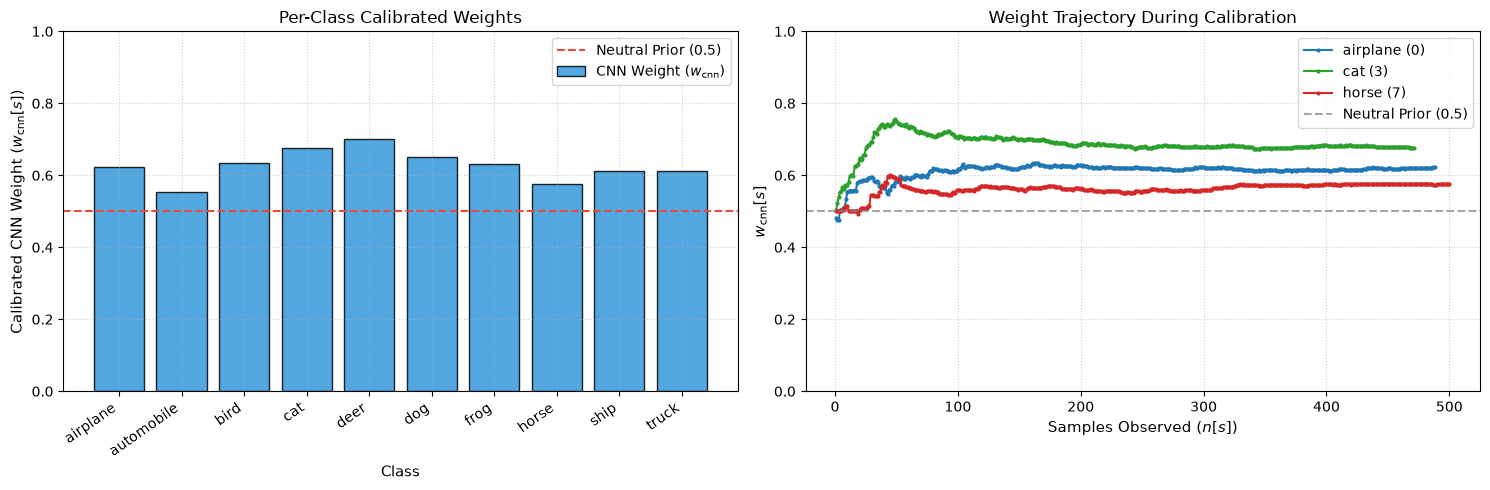

In [5]:
classes = np.arange(NUM_CLASSES)
weights_cnn = [calibrator.get_class_weights(c)[0] for c in classes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of calibrated weights
ax1.bar(classes, weights_cnn, color="#3498db", edgecolor="black", alpha=0.85, label="CNN Weight ($w_{\\mathrm{cnn}}$)")
ax1.axhline(0.5, color="#e74c3c", linestyle="--", linewidth=1.5, label="Neutral Prior (0.5)")
ax1.set_ylim(0.0, 1.0)
ax1.set_xlabel("Class", fontsize=11)
ax1.set_ylabel("Calibrated CNN Weight ($w_{\\mathrm{cnn}}[s]$)", fontsize=11)
ax1.set_title("Per-Class Calibrated Weights", fontsize=12)
ax1.set_xticks(classes)
ax1.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle=":", alpha=0.6)

# Trajectory curves
sample_classes = [0, 3, 7]
colors = ["#1f77b4", "#2ca02c", "#d62728"]
for idx, c in enumerate(sample_classes):
    if trajectory_records[c]:
        steps, w_vals = zip(*trajectory_records[c])
        ax2.plot(steps, w_vals, marker="o", markersize=2, label=f"{CLASS_NAMES[c]} ({c})", color=colors[idx], linewidth=1.5)

ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Neutral Prior (0.5)")
ax2.set_ylim(0.0, 1.0)
ax2.set_xlabel("Samples Observed ($n[s]$)", fontsize=11)
ax2.set_ylabel("$w_{\\mathrm{cnn}}[s]$", fontsize=11)
ax2.set_title("Weight Trajectory During Calibration", fontsize=12)
ax2.legend(loc="best")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("fusion_weight_calibration_plots.png", dpi=300)
plt.show()


## 5. Evaluation on Test Set

At test time, the ground-truth label is unknown. We use a two-pass proxy state estimate:
1. **Pass 1**: Preliminary unweighted consensus $\hat{y}_0 = \arg\max(0.5 \cdot p_{\text{cnn}} + 0.5 \cdot p_{\text{vit}})$.
2. **Pass 2**: Query $w[\hat{y}_0]$. If confidence is low, fall back to global pooled weights.
3. **Final Decision**: $\hat{y} = \arg\max(w_{\text{cnn}}[\hat{y}_0] \cdot p_{\text{cnn}} + w_{\text{vit}}[\hat{y}_0] \cdot p_{\text{vit}})$.


In [6]:
test_probs_cnn = cnn_test["probs"].numpy()
test_probs_vit = vit_test["probs"].numpy()
test_labels = cnn_test["label"].numpy()
N_test = len(test_labels)

test_history = []
w_global_c, w_global_v = calibrator.get_global_weights()

cnn_preds = np.argmax(test_probs_cnn, axis=1)
vit_preds = np.argmax(test_probs_vit, axis=1)
fused_preds = []
naive_50_50_preds = []
global_ablation_preds = []

for i in range(N_test):
    p_c = test_probs_cnn[i]
    p_v = test_probs_vit[i]
    y_true = int(test_labels[i])

    # Baseline 1: Naive 50/50 average
    p_naive = 0.5 * p_c + 0.5 * p_v
    naive_pred = int(np.argmax(p_naive))
    naive_50_50_preds.append(naive_pred)

    # Baseline 2: Global weight ablation
    p_global = w_global_c * p_c + w_global_v * p_v
    global_pred = int(np.argmax(p_global))
    global_ablation_preds.append(global_pred)

    # Proposed: Two-pass proxy prediction
    y_hat0 = int(np.argmax(p_naive))
    conf = calibrator.get_confidence(y_hat0)
    if conf < CONF_THRESHOLD:
        w_c, w_v = w_global_c, w_global_v
    else:
        w_c, w_v = calibrator.get_class_weights(y_hat0)

    p_fused = w_c * p_c + w_v * p_v
    final_pred = int(np.argmax(p_fused))
    fused_preds.append(final_pred)

    r_cnn = 2.0 * float(p_c[y_true]) - 1.0
    r_vit = 2.0 * float(p_v[y_true]) - 1.0

    test_history.append({
        "split": "test",
        "sample_idx": i,
        "state": y_hat0,
        "w_cnn": w_c,
        "w_vit": w_v,
        "r_cnn": r_cnn,
        "r_vit": r_vit,
        "cnn_correct": int(np.argmax(p_c) == y_true),
        "vit_correct": int(np.argmax(p_v) == y_true),
        "fused_pred": final_pred,
        "fused_correct": int(final_pred == y_true),
    })

sar_df = pd.DataFrame(val_history + test_history)
sar_df.to_csv("fusion_sar_log.csv", index=False)
print(f"Saved SAR transitions to fusion_sar_log.csv ({len(sar_df)} records)")


Saved SAR transitions to fusion_sar_log.csv (15000 records)


## 6. Multi-Metric Benchmark

Evaluation across all baselines on the official CIFAR-10 test set.


In [7]:
def compute_metrics(y_true, y_pred, num_classes=NUM_CLASSES):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    
    acc = np.trace(cm) / np.sum(cm) * 100.0
    precisions, recalls, f1s = [], [], []
    
    for c in range(num_classes):
        tp = cm[c, c]
        fp = np.sum(cm[:, c]) - tp
        fn = np.sum(cm[c, :]) - tp
        
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2.0 * p * r) / (p + r) if (p + r) > 0 else 0.0
        
        precisions.append(p * 100.0)
        recalls.append(r * 100.0)
        f1s.append(f1 * 100.0)
        
    macro_p = float(np.mean(precisions))
    macro_r = float(np.mean(recalls))
    macro_f1 = float(np.mean(f1s))
    
    return acc, macro_p, macro_r, macro_f1, f1s, cm

models_eval = [
    ("CNN Branch Only", cnn_preds),
    ("ViT Branch Only", vit_preds),
    ("Naive 50/50 Ensemble", np.array(naive_50_50_preds)),
    ("Global Weight Ablation", np.array(global_ablation_preds)),
    ("Per-Class RL Fusion (Ours)", np.array(fused_preds)),
]

eval_rows = []
f1_dict = {}
cms_dict = {}

for name, preds in models_eval:
    acc, mp, mr, mf1, per_class_f1, cm = compute_metrics(test_labels, preds)
    f1_dict[name] = per_class_f1
    cms_dict[name] = cm
    eval_rows.append({
        "Method": name,
        "Accuracy (%)": f"{acc:.2f}%",
        "Macro Precision (%)": f"{mp:.2f}%",
        "Macro Recall (%)": f"{mr:.2f}%",
        "Macro F1-Score (%)": f"{mf1:.2f}%",
    })

summary_df = pd.DataFrame(eval_rows)
print(summary_df.to_string(index=False))


                    Method Accuracy (%) Macro Precision (%) Macro Recall (%) Macro F1-Score (%)
           CNN Branch Only       91.00%              90.96%           91.00%             90.94%
           ViT Branch Only       79.54%              79.56%           79.54%             79.42%
      Naive 50/50 Ensemble       90.80%              90.76%           90.80%             90.73%
    Global Weight Ablation       91.35%              91.31%           91.35%             91.29%
Per-Class RL Fusion (Ours)       91.15%              91.12%           91.15%             91.08%


## 7. Per-Class F1 Breakdown


 Class ID Class Name CNN F1 (%) ViT F1 (%) Naive 50/50 F1 (%) RL Fused F1 (%) RL Delta vs Best Single
        0   airplane     91.97%     80.45%             91.90%          92.47%                  +0.50%
        1 automobile     95.96%     87.48%             95.47%          95.56%                  -0.41%
        2       bird     87.22%     75.14%             87.52%          87.67%                  +0.44%
        3        cat     80.80%     63.96%             81.12%          81.60%                  +0.80%
        4       deer     90.35%     76.33%             90.56%          90.53%                  +0.18%
        5        dog     85.76%     71.65%             85.56%          86.41%                  +0.66%
        6       frog     93.61%     85.45%             93.41%          93.47%                  -0.15%
        7      horse     93.58%     81.44%             92.43%          93.24%                  -0.34%
        8       ship     95.34%     87.27%             94.97%          95.29%     

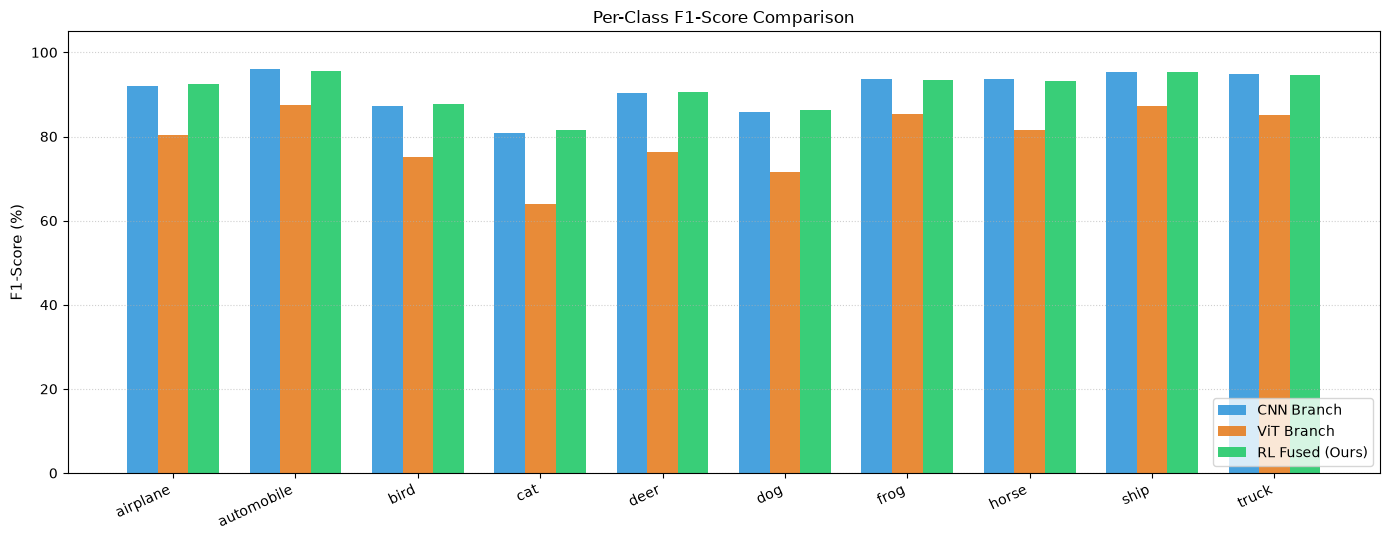

In [8]:
per_class_rows = []
cnn_f1s = f1_dict["CNN Branch Only"]
vit_f1s = f1_dict["ViT Branch Only"]
naive_f1s = f1_dict["Naive 50/50 Ensemble"]
fused_f1s = f1_dict["Per-Class RL Fusion (Ours)"]

for c in range(NUM_CLASSES):
    best_single = max(cnn_f1s[c], vit_f1s[c])
    delta = fused_f1s[c] - best_single
    per_class_rows.append({
        "Class ID": c,
        "Class Name": CLASS_NAMES[c],
        "CNN F1 (%)": f"{cnn_f1s[c]:.2f}%",
        "ViT F1 (%)": f"{vit_f1s[c]:.2f}%",
        "Naive 50/50 F1 (%)": f"{naive_f1s[c]:.2f}%",
        "RL Fused F1 (%)": f"{fused_f1s[c]:.2f}%",
        "RL Delta vs Best Single": f"{delta:+.2f}%",
    })

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))

# Grouped bar plot
x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(x - width, cnn_f1s, width, label='CNN Branch', color='#3498db', alpha=0.9)
ax.bar(x, vit_f1s, width, label='ViT Branch', color='#e67e22', alpha=0.9)
ax.bar(x + width, fused_f1s, width, label='RL Fused (Ours)', color='#2ecc71', alpha=0.95)

ax.set_ylabel('F1-Score (%)', fontsize=11)
ax.set_title('Per-Class F1-Score Comparison', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', fontsize=10)
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("per_class_f1_comparison.png", dpi=300)
plt.show()


## 8. Confusion Matrix Heatmap


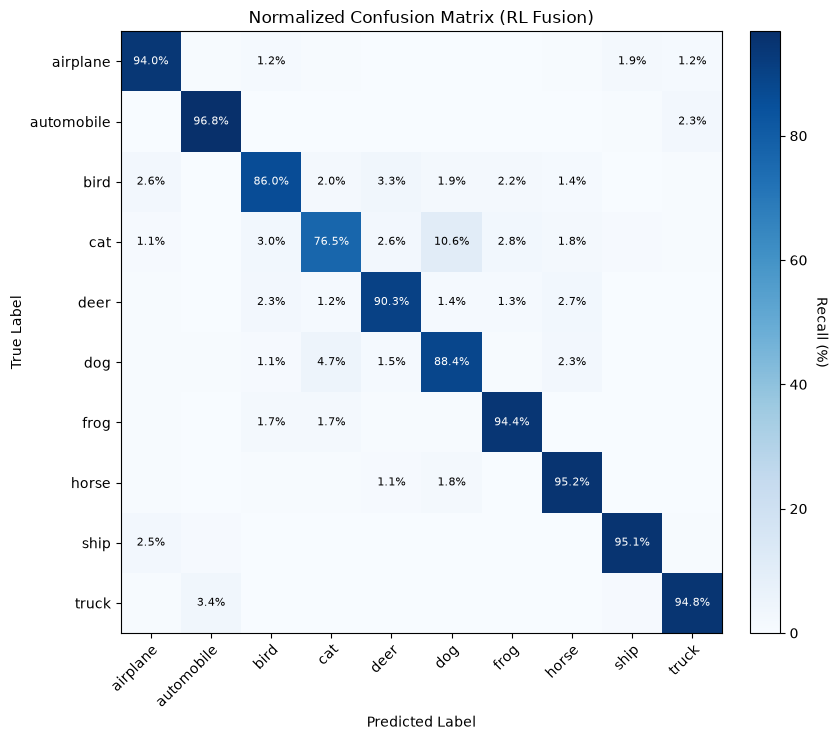

In [9]:
cm = cms_dict["Per-Class RL Fusion (Ours)"]
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100.0

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Recall (%)', rotation=270, labelpad=15, fontsize=10)

ax.set(xticks=np.arange(NUM_CLASSES),
       yticks=np.arange(NUM_CLASSES),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       title='Normalized Confusion Matrix (RL Fusion)',
       ylabel='True Label',
       xlabel='Predicted Label')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm_norm.max() / 2.
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        ax.text(j, i, f"{val:.1f}%" if val >= 1.0 else "",
                ha="center", va="center",
                color="white" if val > thresh else "black",
                fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix_fused.png", dpi=300)
plt.show()
